In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

print("Everything is working!")

Everything is working!


In [3]:
mnist =fetch_openml("mnist_784",version=1)
X,y=mnist.data,mnist.target
print(X.shape)  
print(y.shape)  

(70000, 784)
(70000,)


In [4]:
y=y.astype(int)
X=X/255.0

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [7]:
y_pred = model.predict(X_test)

In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix: ")
cm=confusion_matrix(y_test,y_pred)
print(cm)

Accuracy: 0.9202857142857143
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1343
           1       0.94      0.97      0.96      1600
           2       0.91      0.89      0.90      1380
           3       0.90      0.89      0.90      1433
           4       0.92      0.93      0.93      1295
           5       0.88      0.88      0.88      1273
           6       0.94      0.95      0.95      1396
           7       0.93      0.94      0.93      1503
           8       0.90      0.87      0.88      1357
           9       0.90      0.90      0.90      1420

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000

Confusion Matrix: 
[[1299    1    6    0    3   11   11    4    6    2]
 [   0 1547    6   10    3   12    0    4   16    2]
 [   5   20 1233   20   15   10   21   17   29   10]
 [   6   10

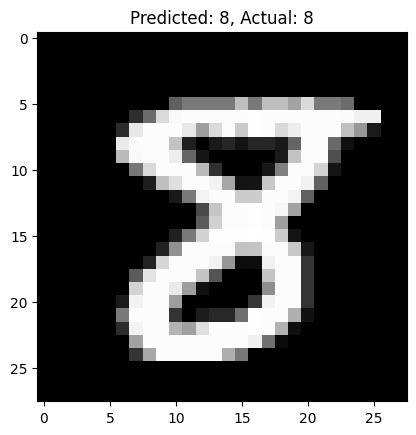

In [23]:
plt.imshow(X_test.iloc[0].values.reshape(28,28), cmap='gray')
plt.title(f"Predicted: {y_pred[0]}, Actual: {y_test.iloc[0]}")
plt.show()

In [10]:
print(np.unique(y_train, return_counts=True))
print(y_train.head())
print(y_test.head())

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([5560, 6277, 5610, 5708, 5529, 5040, 5480, 5790, 5468, 5538]))
47339    5
67456    4
12308    8
32557    0
664      2
Name: class, dtype: int64
46730    8
48393    4
41416    8
34506    7
43725    7
Name: class, dtype: int64


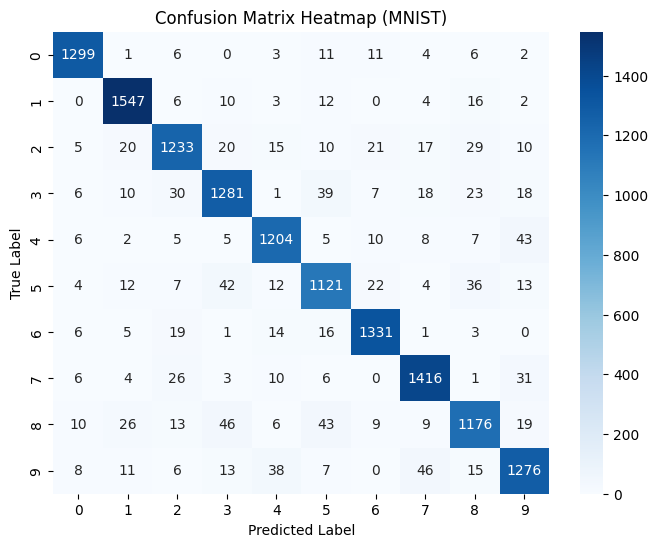

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap (MNIST)")
plt.show()

Neural Networks (MLP):

In [12]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=20
)
mlp.fit(X_train, y_train)

,hidden_layer_sizes,"(128, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,20
,shuffle,True
,random_state,None


In [13]:
mlp_y_pred = mlp.predict(X_test)

In [14]:
print("Accuracy:", accuracy_score(y_test, mlp_y_pred))
print("Classification Report:")
print(classification_report(y_test,mlp_y_pred))
print("Confusion Matrix: ")
mlp_cm=confusion_matrix(y_test,mlp_y_pred)
print(mlp_cm)

Accuracy: 0.9727857142857143
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1343
           1       0.99      0.99      0.99      1600
           2       0.97      0.97      0.97      1380
           3       0.97      0.97      0.97      1433
           4       0.99      0.95      0.97      1295
           5       0.97      0.97      0.97      1273
           6       0.98      0.99      0.99      1396
           7       0.98      0.96      0.97      1503
           8       0.95      0.97      0.96      1357
           9       0.93      0.97      0.95      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000

Confusion Matrix: 
[[1315    1    4    1    1    1    8    2    8    2]
 [   0 1588    1    1    1    0    1    4    3    1]
 [   2    4 1334   10    1    1    3    6   14    5]
 [   1    2

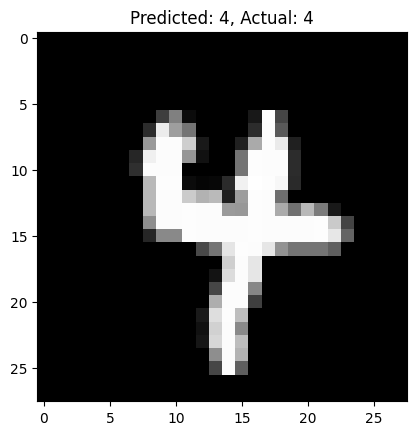

In [18]:
plt.imshow(X_test.iloc[1].values.reshape(28,28), cmap='gray')
plt.title(f"Predicted: {mlp_y_pred[1]}, Actual: {y_test.iloc[1]}")
plt.show()

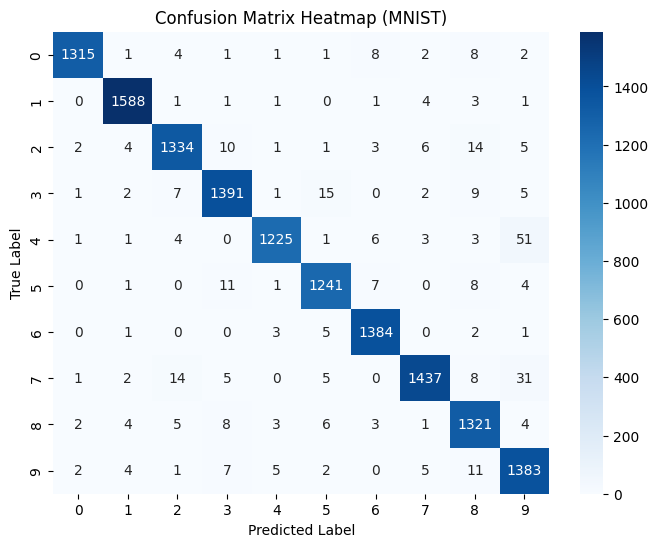

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(mlp_cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap (MNIST)")
plt.show()